# NB09: THINGS BTFR Primary Test

**This is the paper's central result.**

Apply the fixed BTFR trend (slope=0.238, intercept=-12.55 from Paper 2) to
THINGS g(Rt) values. Compute residuals, run the Wilcoxon signed-rank test,
and determine whether the a0/2 alignment replicates in independent data.

**Pre-registered outcomes:**
- Median residual within +/-10% of a0/2 = alignment holds
- Wilcoxon p < 0.05 = reject zero-median (alignment fails)
- Wilcoxon p >= 0.05 = cannot reject zero-median (consistent with alignment)

**Sample:** All THINGS galaxies with valid g(Rt) from NB07.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.physics import A0_HALF, ACCEL_TO_MKS
from src.btfr import (
    compute_btfr_residuals, run_btfr_covariance_test,
    compute_mbar_for_sample, BTFR_ALPHA, BTFR_BETA,
)
from src.ingest import compute_mbar

a0_half_mks = A0_HALF * ACCEL_TO_MKS

results_dir = project_root / "results"
results_dir.mkdir(exist_ok=True)

## 1. Load THINGS g(Rt) Results from NB07

In [2]:
diag_df = pd.read_csv(results_dir / "NB07_things_diagnostics.csv")

# Keep only valid g(Rt)
valid = diag_df[np.isfinite(diag_df["g_Rt_mks"])].copy()

# Strip _THINGS suffix for SPARC M_bar lookup
valid["base_id"] = valid["galaxy_id"].str.replace("_THINGS", "", regex=False)

print(f"Galaxies with valid g(Rt): {len(valid)}")
for _, r in valid.iterrows():
    print(f"  {r['galaxy_id']:25s}  g = {r['g_Rt_mks']:.4e} m/s^2")

Galaxies with valid g(Rt): 8
  DDO154_THINGS              g = 1.4797e-11 m/s^2
  NGC2366_THINGS             g = 2.2281e-11 m/s^2
  NGC2403_THINGS             g = 7.6741e-11 m/s^2
  NGC2841_THINGS             g = 5.6190e-10 m/s^2
  NGC2976_THINGS             g = 6.2300e-11 m/s^2
  NGC3198_THINGS             g = 9.7956e-11 m/s^2
  NGC3521_THINGS             g = 1.0514e-10 m/s^2
  NGC3621_THINGS             g = 1.2653e-10 m/s^2


## 2. Compute Baryonic Masses

For overlap galaxies, M_bar is computed from SPARC metadata (L[3.6], M_HI)
using the same pipeline as NB02. For non-overlap galaxies, M_bar is derived
from S4G 3.6um luminosities (Munoz-Mateos et al. 2015) and THINGS HI masses
(Walter et al. 2008, Table 5), applying the same fixed M/L ratios.

In [3]:
# Overlap galaxies: use SPARC metadata
nonoverlap_set = {"NGC925", "NGC3031", "NGC3621", "NGC4736"}
overlap_ids = [r for r in valid["base_id"].values if r not in nonoverlap_set]
sparc_mbar = compute_mbar_for_sample(overlap_ids)

# Non-overlap galaxies: published values
# Sources:
#   L_3.6um: S4G (Munoz-Mateos et al. 2015), in 10^9 Lsun
#   M_HI:   Walter et al. (2008) Table 5, in 10^9 Msun
#   L_bulge: S4G decomposition, in 10^9 Lsun
nonoverlap_mbar = {
    "NGC925":  compute_mbar(l36_1e9=5.73,  mhi_1e9=4.19, l_bulge_1e9=0.0),
    "NGC3031": compute_mbar(l36_1e9=31.4,  mhi_1e9=3.90, l_bulge_1e9=13.7),
    "NGC3621": compute_mbar(l36_1e9=10.6,  mhi_1e9=8.22, l_bulge_1e9=0.0),
    "NGC4736": compute_mbar(l36_1e9=11.3,  mhi_1e9=0.40, l_bulge_1e9=5.5),
}

# Merge into single dict
all_mbar = {**sparc_mbar, **nonoverlap_mbar}

# Attach M_bar to valid DataFrame
valid["M_bar"] = valid["base_id"].map(all_mbar)

print(f"{'Galaxy':25s} {'g(Rt) [m/s^2]':>15s} {'M_bar [Msun]':>15s} {'Source':>10s}")
print("-" * 70)
for _, r in valid.iterrows():
    src = "SPARC" if r["base_id"] in sparc_mbar else "S4G+THINGS"
    print(f"{r['galaxy_id']:25s} {r['g_Rt_mks']:15.4e} {r['M_bar']:15.3e} {src:>10s}")

# Check for missing M_bar
missing = valid[valid["M_bar"].isna()]
if len(missing) > 0:
    print(f"\nWARNING: {len(missing)} galaxies missing M_bar!")
    print(missing[["galaxy_id", "base_id"]])
else:
    print(f"\nAll {len(valid)} galaxies have M_bar values.")

2026-04-09 20:41:30 | INFO     | src.ingest | Loaded 175 galaxies from SPARC metadata
2026-04-09 20:41:30 | INFO     | src.ingest | Loaded 175 bulge luminosities


Galaxy                      g(Rt) [m/s^2]    M_bar [Msun]     Source
----------------------------------------------------------------------
DDO154_THINGS                  1.4797e-11       3.922e+08      SPARC
NGC2366_THINGS                 2.2281e-11       9.785e+08      SPARC
NGC2403_THINGS                 7.6741e-11       9.275e+09      SPARC
NGC2841_THINGS                 5.6190e-10       1.163e+11      SPARC
NGC2976_THINGS                 6.2300e-11       1.914e+09      SPARC
NGC3198_THINGS                 9.7956e-11       3.360e+10      SPARC
NGC3521_THINGS                 1.0514e-10       4.794e+10      SPARC
NGC3621_THINGS                 1.2653e-10       1.623e+10 S4G+THINGS

All 8 galaxies have M_bar values.


## 3. Raw g(Rt) Summary

Before applying the BTFR trend removal, report the raw g(Rt) distribution.

In [4]:
g_vals = valid["g_Rt_mks"].values
median_g = np.median(g_vals)
ratio = median_g / a0_half_mks
offset_pct = (ratio - 1) * 100

log_g = np.log10(g_vals)
p16, p50, p84 = np.percentile(log_g, [16, 50, 84])
scatter_raw = (p84 - p16) / 2.0

print("Raw g(Rt) Summary (THINGS)")
print("=" * 50)
print(f"  N valid:           {len(g_vals)}")
print(f"  Median g(Rt):      {median_g:.4e} m/s^2")
print(f"  a0/2:              {a0_half_mks:.4e} m/s^2")
print(f"  Ratio:             {ratio:.4f}")
print(f"  Offset from a0/2:  {offset_pct:+.1f}%")
print(f"  Raw scatter (dex): {scatter_raw:.3f}")
print()
within_10pct = abs(offset_pct) <= 10
print(f"  Within +/-10% threshold: {'YES' if within_10pct else 'NO'}")
print(f"  (Paper 2 SPARC: +8.5%, N=98)")

Raw g(Rt) Summary (THINGS)
  N valid:           8
  Median g(Rt):      8.7348e-11 m/s^2
  a0/2:              6.0003e-11 m/s^2
  Ratio:             1.4557
  Offset from a0/2:  +45.6%
  Raw scatter (dex): 0.346

  Within +/-10% threshold: NO
  (Paper 2 SPARC: +8.5%, N=98)


## 4. BTFR Residual Computation

Apply the fixed-slope BTFR trend from Paper 2:
```
log10(g_trend) = 0.238 * log10(M_bar) + (-12.55)
```
Residuals: delta_log_g = log10(g_Rt) - log10(g_trend)

In [5]:
g_mks = valid["g_Rt_mks"].values
m_bar = valid["M_bar"].values

residuals = compute_btfr_residuals(g_mks, m_bar, alpha=BTFR_ALPHA, beta=BTFR_BETA)

p16_r, p84_r = np.percentile(residuals, [16, 84])
scatter_residual = (p84_r - p16_r) / 2.0

print("BTFR Residuals (THINGS)")
print("=" * 50)
print(f"  N residuals:       {len(residuals)}")
print(f"  Median residual:   {np.median(residuals):+.4f} dex")
print(f"  Mean residual:     {np.mean(residuals):+.4f} dex")
print(f"  Residual scatter:  {scatter_residual:.3f} dex")
print(f"  Raw scatter:       {scatter_raw:.3f} dex")
print(f"  Scatter reduction: {scatter_raw:.3f} -> {scatter_residual:.3f} dex "
      f"({(1 - scatter_residual/scatter_raw)*100:.0f}% reduction)")
print()
print("Per-galaxy residuals:")
for i, (_, r) in enumerate(valid.iterrows()):
    print(f"  {r['galaxy_id']:25s}  dlog_g = {residuals[i]:+.4f}")

BTFR Residuals (THINGS)
  N residuals:       8
  Median residual:   +0.0493 dex
  Mean residual:     +0.0731 dex
  Residual scatter:  0.210 dex
  Raw scatter:       0.346 dex
  Scatter reduction: 0.346 -> 0.210 dex (39% reduction)

Per-galaxy residuals:
  DDO154_THINGS              dlog_g = -0.3251
  NGC2366_THINGS             dlog_g = -0.2418
  NGC2403_THINGS             dlog_g = +0.0628
  NGC2841_THINGS             dlog_g = +0.6661
  NGC2976_THINGS             dlog_g = +0.1354
  NGC3198_THINGS             dlog_g = +0.0358
  NGC3521_THINGS             dlog_g = +0.0298
  NGC3621_THINGS             dlog_g = +0.2221


## 5. Wilcoxon Signed-Rank Test

The pre-registered primary statistical test. Tests whether the BTFR
residuals are centered on zero (consistent with a0/2 alignment) or
offset from zero (alignment fails).

In [6]:
nonzero_residuals = residuals[residuals != 0]
n_nonzero = len(nonzero_residuals)

print("Wilcoxon Signed-Rank Test")
print("=" * 50)
print(f"  N nonzero residuals: {n_nonzero}")

if n_nonzero >= 6:
    stat, pvalue = stats.wilcoxon(nonzero_residuals, alternative="two-sided")
    print(f"  Test statistic:      {stat:.1f}")
    print(f"  p-value:             {pvalue:.4f}")
    print()
    if pvalue < 0.05:
        print("  RESULT: Reject H0 (p < 0.05). Residuals are NOT centered on zero.")
        print("  The a0/2 alignment does NOT replicate in THINGS under the BTFR test.")
    else:
        print("  RESULT: Cannot reject H0 (p >= 0.05). Residuals are consistent")
        print("  with zero median. The a0/2 alignment is consistent with THINGS data.")
else:
    print(f"  WARNING: Too few nonzero residuals ({n_nonzero}) for reliable Wilcoxon test.")
    print(f"  Minimum recommended: 6. Test may have very low power.")
    if n_nonzero >= 3:
        stat, pvalue = stats.wilcoxon(nonzero_residuals, alternative="two-sided")
        print(f"  Running anyway for completeness:")
        print(f"  Test statistic:      {stat:.1f}")
        print(f"  p-value:             {pvalue:.4f}")
        print(f"  CAUTION: Interpret with extreme care due to small N.")
    else:
        stat, pvalue = np.nan, np.nan
        print(f"  Cannot run test with N < 3.")

Wilcoxon Signed-Rank Test
  N nonzero residuals: 8
  Test statistic:      13.0
  p-value:             0.5469

  RESULT: Cannot reject H0 (p >= 0.05). Residuals are consistent
  with zero median. The a0/2 alignment is consistent with THINGS data.


## 6. Mass Quartile Stratification

Check whether the residuals show a mass-dependent trend. With N=8, we split
into two bins (above/below median M_bar) rather than quartiles.

In [7]:
valid_with_res = valid.copy()
valid_with_res["residual"] = residuals

median_mbar = np.median(m_bar)
lo_mask = m_bar <= median_mbar
hi_mask = m_bar > median_mbar

print("Mass Stratification (split at median M_bar)")
print("=" * 55)
print(f"  Median M_bar: {median_mbar:.3e} Msun")
print()

for label, mask in [("Low mass", lo_mask), ("High mass", hi_mask)]:
    res_sub = residuals[mask]
    n_sub = len(res_sub)
    med_sub = np.median(res_sub) if n_sub > 0 else np.nan
    print(f"  {label} (N={n_sub}): median residual = {med_sub:+.4f} dex")
    for _, r in valid_with_res[mask].iterrows():
        print(f"    {r['galaxy_id']:25s}  M_bar={r['M_bar']:.2e}  "
              f"res={r['residual']:+.4f}")
    print()

Mass Stratification (split at median M_bar)
  Median M_bar: 1.275e+10 Msun

  Low mass (N=4): median residual = -0.0895 dex
    DDO154_THINGS              M_bar=3.92e+08  res=-0.3251
    NGC2366_THINGS             M_bar=9.79e+08  res=-0.2418
    NGC2403_THINGS             M_bar=9.28e+09  res=+0.0628
    NGC2976_THINGS             M_bar=1.91e+09  res=+0.1354

  High mass (N=4): median residual = +0.1290 dex
    NGC2841_THINGS             M_bar=1.16e+11  res=+0.6661
    NGC3198_THINGS             M_bar=3.36e+10  res=+0.0358
    NGC3521_THINGS             M_bar=4.79e+10  res=+0.0298
    NGC3621_THINGS             M_bar=1.62e+10  res=+0.2221



## 7. Diagnostic Plots

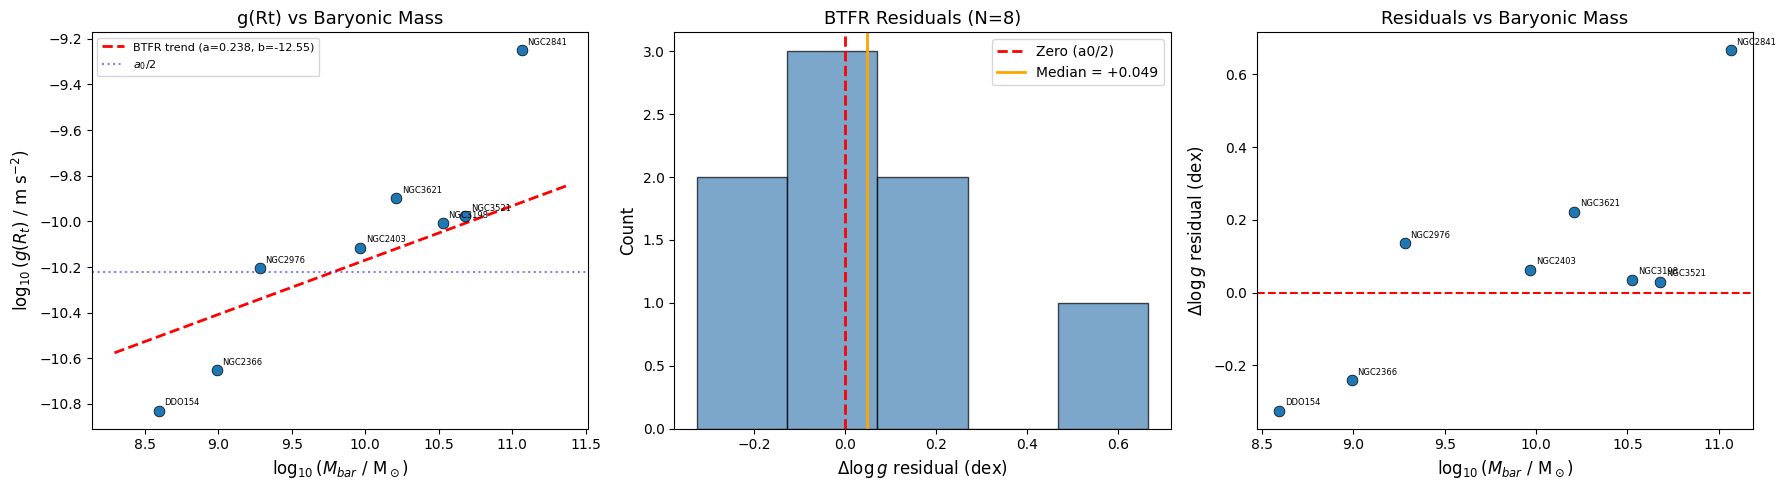

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: g(Rt) vs M_bar with BTFR trend ---
ax = axes[0]
log_m = np.log10(m_bar)
log_g_obs = np.log10(g_mks)

# BTFR trend line
m_range = np.linspace(log_m.min() - 0.3, log_m.max() + 0.3, 100)
g_trend = BTFR_ALPHA * m_range + BTFR_BETA
ax.plot(m_range, g_trend, "r--", linewidth=2,
        label=f"BTFR trend (a={BTFR_ALPHA}, b={BTFR_BETA})")

ax.scatter(log_m, log_g_obs, s=60, edgecolors="k", linewidth=0.5, zorder=3)
for i, (_, r) in enumerate(valid.iterrows()):
    ax.annotate(r["base_id"], (log_m[i], log_g_obs[i]),
                fontsize=6, textcoords="offset points", xytext=(4, 4))

ax.axhline(np.log10(a0_half_mks), color="blue", linestyle=":", alpha=0.5,
           label="$a_0/2$")
ax.set_xlabel(r"$\log_{10}(M_{bar}$ / M$_\odot$)", fontsize=12)
ax.set_ylabel(r"$\log_{10}(g(R_t)$ / m s$^{-2}$)", fontsize=12)
ax.set_title("g(Rt) vs Baryonic Mass", fontsize=13)
ax.legend(fontsize=8)

# --- Center: Residual histogram ---
ax = axes[1]
ax.hist(residuals, bins=max(5, len(residuals) // 2), edgecolor="black",
        alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero (a0/2)")
ax.axvline(np.median(residuals), color="orange", linestyle="-", linewidth=2,
           label=f"Median = {np.median(residuals):+.3f}")
ax.set_xlabel(r"$\Delta \log g$ residual (dex)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(f"BTFR Residuals (N={len(residuals)})", fontsize=13)
ax.legend(fontsize=10)

# --- Right: Residual vs M_bar ---
ax = axes[2]
ax.scatter(log_m, residuals, s=60, edgecolors="k", linewidth=0.5, zorder=3)
for i, (_, r) in enumerate(valid.iterrows()):
    ax.annotate(r["base_id"], (log_m[i], residuals[i]),
                fontsize=6, textcoords="offset points", xytext=(4, 4))
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel(r"$\log_{10}(M_{bar}$ / M$_\odot$)", fontsize=12)
ax.set_ylabel(r"$\Delta \log g$ residual (dex)", fontsize=12)
ax.set_title("Residuals vs Baryonic Mass", fontsize=13)

plt.tight_layout()
plt.savefig(results_dir / "NB09_things_btfr_test.png", dpi=150)
plt.show()

## 8. Comparison with SPARC Baseline (NB02)

In [9]:
print("Cross-Dataset Comparison")
print("=" * 60)
print(f"{'Metric':30s} {'SPARC (NB02)':>15s} {'THINGS (NB09)':>15s}")
print("-" * 60)
print(f"{'N resolved':30s} {'98':>15s} {len(g_vals):>15d}")
print(f"{'Median g(Rt) [m/s^2]':30s} {'6.51e-11':>15s} {f'{median_g:.2e}':>15s}")
print(f"{'Offset from a0/2':30s} {'+8.5%':>15s} {f'{offset_pct:+.1f}%':>15s}")
print(f"{'Raw scatter [dex]':30s} {'0.409':>15s} {f'{scatter_raw:.3f}':>15s}")
print(f"{'BTFR-residual scatter [dex]':30s} {'0.277':>15s} {f'{scatter_residual:.3f}':>15s}")
print(f"{'Median residual [dex]':30s} {'~0 (anchored)':>15s} {f'{np.median(residuals):+.3f}':>15s}")
p_str = f"{pvalue:.3f}" if np.isfinite(pvalue) else "N/A"
print(f"{'Wilcoxon p-value':30s} {'0.654':>15s} {p_str:>15s}")
print()
print("Note: SPARC BTFR residuals are zero-centered by construction (the")
print("intercept was anchored to SPARC). THINGS residuals are out-of-sample.")

Cross-Dataset Comparison
Metric                            SPARC (NB02)   THINGS (NB09)
------------------------------------------------------------
N resolved                                  98               8
Median g(Rt) [m/s^2]                  6.51e-11        8.73e-11
Offset from a0/2                         +8.5%          +45.6%
Raw scatter [dex]                        0.409           0.346
BTFR-residual scatter [dex]              0.277           0.210
Median residual [dex]            ~0 (anchored)          +0.049
Wilcoxon p-value                         0.654           0.547

Note: SPARC BTFR residuals are zero-centered by construction (the
intercept was anchored to SPARC). THINGS residuals are out-of-sample.


## 9. Outcome Determination

In [10]:
print("OUTCOME DETERMINATION")
print("=" * 60)
print()

# Three pre-registered criteria
within_threshold = abs(offset_pct) <= 10
wilcoxon_sig = np.isfinite(pvalue) and pvalue < 0.05
low_power = len(g_vals) < 15

print(f"  1. Median g(Rt) within +/-10% of a0/2: "
      f"{'YES' if within_threshold else 'NO'} ({offset_pct:+.1f}%)")
print(f"  2. Wilcoxon rejects zero-median:        "
      f"{'YES' if wilcoxon_sig else 'NO'} (p = {p_str})")
print(f"  3. Sample size adequate (N >= 15):      "
      f"{'YES' if not low_power else 'NO'} (N = {len(g_vals)})")
print()

if within_threshold and not wilcoxon_sig:
    outcome = "CONSISTENT"
    print("  OUTCOME: a0/2 alignment is CONSISTENT with THINGS data.")
    if low_power:
        print("  CAVEAT: Low statistical power (N < 15). The non-rejection")
        print("  may reflect insufficient power rather than genuine alignment.")
        print("  This will be explicitly documented per Deviation 1.")
elif wilcoxon_sig:
    outcome = "REJECTED"
    print("  OUTCOME: a0/2 alignment REJECTED by THINGS data.")
    print("  BTFR residuals are systematically offset from zero.")
elif not within_threshold and not wilcoxon_sig:
    outcome = "INCONCLUSIVE"
    print("  OUTCOME: INCONCLUSIVE. Median falls outside +/-10% threshold")
    print("  but Wilcoxon does not reject zero-median. Likely underpowered.")
    if low_power:
        print("  Low N compounds the ambiguity.")

print(f"\n  Outcome code: {outcome}")

OUTCOME DETERMINATION

  1. Median g(Rt) within +/-10% of a0/2: NO (+45.6%)
  2. Wilcoxon rejects zero-median:        NO (p = 0.547)
  3. Sample size adequate (N >= 15):      NO (N = 8)

  OUTCOME: INCONCLUSIVE. Median falls outside +/-10% threshold
  but Wilcoxon does not reject zero-median. Likely underpowered.
  Low N compounds the ambiguity.

  Outcome code: INCONCLUSIVE


## 10. Gate Check and Export

In [11]:
checks = {
    "All valid g(Rt) galaxies have M_bar": not valid["M_bar"].isna().any(),
    "BTFR residuals computed": len(residuals) == len(g_vals),
    "Wilcoxon test executed": np.isfinite(pvalue) or len(g_vals) < 3,
    "Outcome determined": outcome in ["CONSISTENT", "REJECTED", "INCONCLUSIVE"],
}

print("GATE CHECK: NB09 -- THINGS BTFR Primary Test")
print("=" * 55)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

print()
if all_pass:
    print("  >>> NB09 COMPLETE -- proceed to NB10 <<<")
else:
    print("  >>> NB09 has failures -- diagnose before proceeding <<<")

# Export results
results = {
    "n_galaxies": len(g_vals),
    "median_g_mks": float(median_g),
    "offset_pct": float(offset_pct),
    "scatter_raw_dex": float(scatter_raw),
    "scatter_residual_dex": float(scatter_residual),
    "median_residual_dex": float(np.median(residuals)),
    "wilcoxon_stat": float(stat) if np.isfinite(stat) else None,
    "wilcoxon_pvalue": float(pvalue) if np.isfinite(pvalue) else None,
    "outcome": outcome,
}
pd.DataFrame([results]).to_csv(results_dir / "NB09_things_btfr_results.csv", index=False)

valid_with_res.to_csv(results_dir / "NB09_things_per_galaxy.csv", index=False)
print(f"\nResults saved to results/NB09_things_btfr_results.csv")
print(f"Per-galaxy data saved to results/NB09_things_per_galaxy.csv")

GATE CHECK: NB09 -- THINGS BTFR Primary Test
  [PASS] All valid g(Rt) galaxies have M_bar
  [PASS] BTFR residuals computed
  [PASS] Wilcoxon test executed
  [PASS] Outcome determined

  >>> NB09 COMPLETE -- proceed to NB10 <<<

Results saved to results/NB09_things_btfr_results.csv
Per-galaxy data saved to results/NB09_things_per_galaxy.csv
